# Definición del Problema: OneMax (The OneMax Problem)

El problema OneMax es uno de los "benchmarks" o problemas de referencia más sencillos y fundamentales en el campo de la computación evolutiva.

Es un problema de optimización matemática donde el objetivo es encontrar una cadena de bits (ceros y unos) que maximice la suma de sus elementos.

***Descripción Técnica:***
* **Espacio de Búsqueda**: Dado un vector de longitud $L$, existen $2^L$ combinaciones posibles.
* **Individuo**: Un cromosoma representado por una lista de números binarios $[b_1, b_2, ..., b_L]$.
* **Objetivo**: Maximizar la función de aptitud. El valor máximo posible es igual a la longitud del vector ($L$).

***Especificaciones del Problema***

**Longitud del Cromosoma:** El vector debe tener exactamente 20 genes.

*Tipo de Gen: Binario (valores posibles: 0 o 1).*

**Función de Aptitud (Fitness):** La calidad de cada solución será igual a la suma de sus genes.

*Ejemplo: El fitness de [1, 0, 1, 0, 0] es 2.*

**Condición de Éxito:** El algoritmo debe converger hacia una solución donde todos los genes sean 1 (Fitness = 20).

# 1. Configuración del Entorno

Utilizaremos dos de las librerías más potentes y utilizadas en el ecosistema de Python: PyGAD (por su simplicidad y enfoque práctico) y DEAP (por su flexibilidad y robustez profesional).

In [ ]:
!pip install pygad deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.8 MB/s eta 0:00:00


# 2. Implementación con PyGAD
Esta librería es ideal para una implementación rápida y orientada a objetos.

In [ ]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. Función de Aptitud
def fitness_func(ga_instance, solution, solution_idx):
    return np.sum(solution)

# 2. Configurar el Algoritmo
ga_instance = pygad.GA(
    num_generations=50,
    num_parents_mating=5,
    fitness_func=fitness_func,
    sol_per_pop=20,
    num_genes=20,
    init_range_low=0,
    init_range_high=2,
    random_mutation_min_val=0,
    random_mutation_max_val=2,
    mutation_by_replacement=True,
    gene_type=int,
    parent_selection_type="sss", # Steady State Selection
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=10)

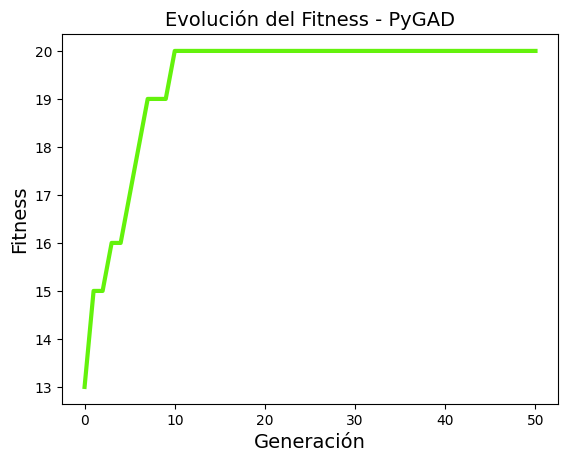

Mejor Solución: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Valor de Aptitud: 20


In [ ]:
# 3. Ejecución
ga_instance.run()

# 4. Generación del Gráfico
# PyGAD guarda internamente el historial de fitness
ga_instance.plot_fitness(title="Evolución del Fitness - PyGAD", xlabel="Generación", ylabel="Fitness")
plt.show()

# 5. Resultados
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"Mejor Solución: {solution}")
print(f"Valor de Aptitud: {solution_fitness}")

**Glosario de Funciones y Parámetros PyGAD**

* **`pygad.GA`**: Es la clase principal de la librería. Se utiliza para crear y configurar la instancia del algoritmo genético que ejecutará la optimización.

* **`num_generations`**: Define el número total de iteraciones o ciclos evolutivos. Es el límite de tiempo que tiene el algoritmo para encontrar la solución.

* **`sol_per_pop`**: Representa el tamaño de la población. Es la cantidad de individuos (soluciones candidatas) que existen en cada generación.

* **`num_parents_mating`**: Indica cuántos individuos de la población actual serán seleccionados como "padres" para generar la descendencia de la siguiente generación.

* **`fitness_func`**: Es la referencia a la función de aptitud definida por el usuario. El algoritmo la llama automáticamente para evaluar qué tan buena es cada solución.

* **`parent_selection_type`**: Determina el método para elegir a los padres. Algunos valores comunes son `sss` (Selección de Estado Estacionario), `rws` (Ruleta) o `tournament` (Torneo).

* **`crossover_type`**: Define cómo se combinarán los genes de los padres. Opciones como `single_point` (un punto de corte) o `two_points` definen la estructura del intercambio.

* **`mutation_percent_genes`**: Es el parámetro que controla la variabilidad. Define qué porcentaje de los genes de un individuo cambiarán aleatoriamente para explorar nuevas soluciones.

# 2. Implementación con DEAP
*(Gráfico manual con Logbook)*

En DEAP, debemos registrar las estadísticas manualmente durante la ejecución utilizando un objeto Statistics. El algoritmo nos devolverá un Logbook que luego graficaremos.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

In [ ]:
# 1. Configuración de Tipos (Maximización)
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# 2. Configuración del Toolbox
toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, 20)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# 3. Operadores
def evalOneMax(individual):
    return sum(individual),

toolbox.register("evaluate", evalOneMax)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

# --- NUEVO: Configuración de Estadísticas y Hall of Fame ---
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", np.max)
stats.register("avg", np.mean)

hof = tools.HallOfFame(1) # El "Salón de la Fama" guardará al mejor individuo absoluto

RESULTADO DEL HALL OF FAME
Mejor individuo histórico: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Fitness del mejor individuo: 20.0


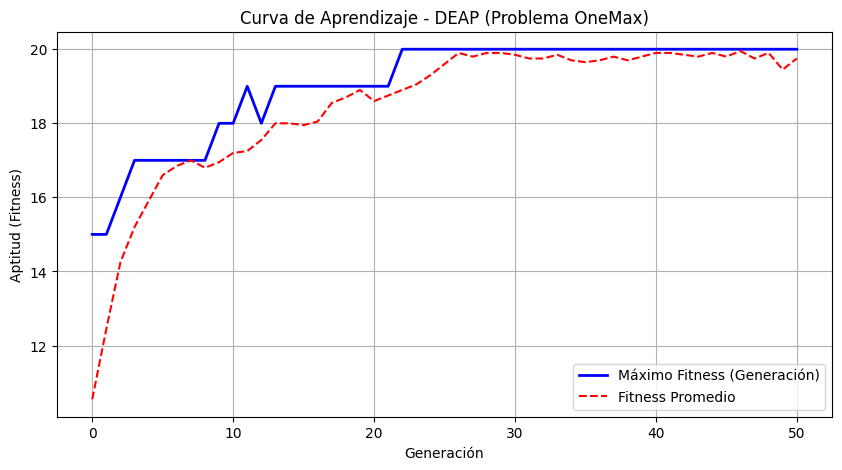

In [ ]:
# 4. Ejecución del Algoritmo
pop = toolbox.population(n=20)
pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=50,
                                   stats=stats, halloffame=hof, verbose=False)

# --- NUEVO: Visualización del Resultado del Hall of Fame ---
print("="*30)
print("RESULTADO DEL HALL OF FAME")
print("="*30)
print(f"Mejor individuo histórico: {hof[0]}")
print(f"Fitness del mejor individuo: {hof[0].fitness.values[0]}")
print("="*30)

# --- NUEVO: Gráfico de Evolución ---
gen = logbook.select("gen")
fit_max = logbook.select("max")
fit_avg = logbook.select("avg")

plt.figure(figsize=(10, 5))
plt.plot(gen, fit_max, label="Máximo Fitness (Generación)", color="blue", linewidth=2)
plt.plot(gen, fit_avg, label="Fitness Promedio", color="red", linestyle="--")
plt.title("Curva de Aprendizaje - DEAP (Problema OneMax)")
plt.xlabel("Generación")
plt.ylabel("Aptitud (Fitness)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Glosario de Funciones y Parámetros DEAP**

* **`creator`**: Es un módulo de metaprogramación que permite crear nuevas clases de forma dinámica, como el tipo de fitness (si buscamos maximizar o minimizar) e identificar la estructura del individuo.

* **`base.Toolbox`**: Funciona como un contenedor o "caja de herramientas" donde el programador debe registrar cada una de las funciones y operadores que usará el algoritmo.

* **`tools.initRepeat`**: Es un inicializador que llama repetidamente a una función para llenar un recipiente, por ejemplo, para crear 20 genes dentro de un individuo o 50 individuos dentro de una población.

* **`tools.cxTwoPoint`**: Representa el operador de cruce de dos puntos. Intercambia secciones de código genético entre dos padres usando dos puntos de corte aleatorios.

* **`tools.mutFlipBit`**: Un operador de mutación específico para codificación binaria. Selecciona genes al azar y cambia un 0 por un 1, o viceversa, según la probabilidad indicada.

* **`tools.selTournament`**: Ejecuta la selección por torneo. Elige un grupo pequeño de individuos al azar y selecciona al mejor de ese grupo para ser padre.

* **`algorithms.eaSimple`**: Es un algoritmo evolutivo preconfigurado que implementa el ciclo básico (Evaluación, Selección, Cruce y Mutación) de forma automática.

* **`cxpb` / `mutpb`**: Son las probabilidades de cruce y mutación, respectivamente. Se expresan en valores decimales entre 0 y 1 (por ejemplo, 0.5 equivale al 50% de probabilidad de que ocurra el evento).

En sistemas evolutivos, el **Hall of Fame** es un contenedor independiente de la población actual que almacena de forma persistente a los mejores individuos encontrados a lo largo de toda la ejecución.

* **¿Por qué es importante?**: Debido a la naturaleza estocástica (aleatoria) de los algoritmos genéticos, es posible que el mejor individuo de la generación 40 se pierda en la generación 41 debido a una mutación desafortunada o un cruce ineficiente.

* **Garantía de calidad**: El HoF asegura que, al finalizar el proceso, siempre tengamos acceso a la "medalla de oro" histórica del experimento, independientemente de cómo haya terminado la última población.

# 3. Conclusión

Observa que mientras PyGAD encapsula todo en una sola clase, DEAP te obliga a registrar explícitamente cada paso (selección, cruce, mutación)